I want to see the effects of the new lr scheduling

In [29]:
# Add project root to path so we can import from data_manipulation and model
import sys
from pathlib import Path

def _find_project_root():
    cwd = Path.cwd()
    if (cwd / "data_manipulation").is_dir():
        return cwd
    if (cwd.parent / "data_manipulation").is_dir():
        return cwd.parent
    return cwd  # fallback

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [30]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from functools import partial
import numpy as np


# Imports from data_manipulation and model
from data_manipulation.data_split import create_dataloader, DemandDataset
from model.functions import pinball_loss, rmse, train, get_test_loss, pinball_loss_tensor, pinball_loss_sum, normalize_batch, compute_mean_std

In [31]:
class thread_net(nn.Module):

    @staticmethod
    def _mlp(sizes: list[int]) -> nn.Sequential:
        """Linear layers with ReLU between; no ReLU after the last linear."""
        if len(sizes) < 2:
            raise ValueError("layer_list needs at least [input_dim, output_dim]")
        layers: list[nn.Module] = []
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            if i < len(sizes) - 2:
                layers.append(nn.ReLU())
        return nn.Sequential(*layers)

    def __init__(self, layer_list=[12, 40, 40, 40, 1], num_nets=500):
        super().__init__()
        self.layer_list = list(layer_list)
        self.nets = nn.ModuleList(
            [self._mlp(self.layer_list) for _ in range(num_nets)]
        )
        self.num_nets = num_nets

    def forward(self, x):
        outs = [net(x[:, i::self.num_nets]) for i, net in enumerate(self.nets)]
        return torch.cat(outs, dim=1)

In [32]:
all_specs = [
    "sales",
    "7_day_rolling_ema",	
    "30_day_rolling_ema",
    "90_day_rolling_ema",
    "30_day_rolling_min",
    "5_day_lag",
    "6_day_lag",
    "7_day_lag",
    "dif_180_day",
]

In [33]:
# Get data for spec
train_loader, val_loader, test_loader = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    specs=all_specs,
    combine_items=True,
    combine_stores=True
    )

In [34]:
h_cost = 1
l_cost = 3
num_epochs = 2000


In [35]:
num_nets = train_loader.dataset.y.shape[1]
in_per_net = train_loader.dataset.x.shape[1] // num_nets
layer_list = [in_per_net, 80, 80, 80, 1]  


First compute with Normalization

In [36]:
net_1 = thread_net(layer_list=layer_list, num_nets=num_nets)

loss = partial(pinball_loss_sum, h_cost=h_cost, l_cost=l_cost)
og_loss = partial(pinball_loss, h_cost=h_cost, l_cost=l_cost)
loss_tensor = partial(pinball_loss_tensor, h_cost=h_cost, l_cost=l_cost)
optimizer = torch.optim.Adam(net_1.parameters(), lr=0.05)

mean, std = compute_mean_std(train_loader, device="cpu")
normalize_func = partial(normalize_batch, mean=mean, std=std)

train_losses, val_losses = train(net_1, optimizer, loss, train_loader, val_loader, epochs=num_epochs, eval_interval=10, device="cpu", use_one_cycle_lr=True, normalize_func=normalize_func)

test_loss = get_test_loss(net_1, test_loader, og_loss, "cpu")

Training: 100%|██████████| 2000/2000 [10:33<00:00,  3.16step/s, train_loss=38777.8789]                     


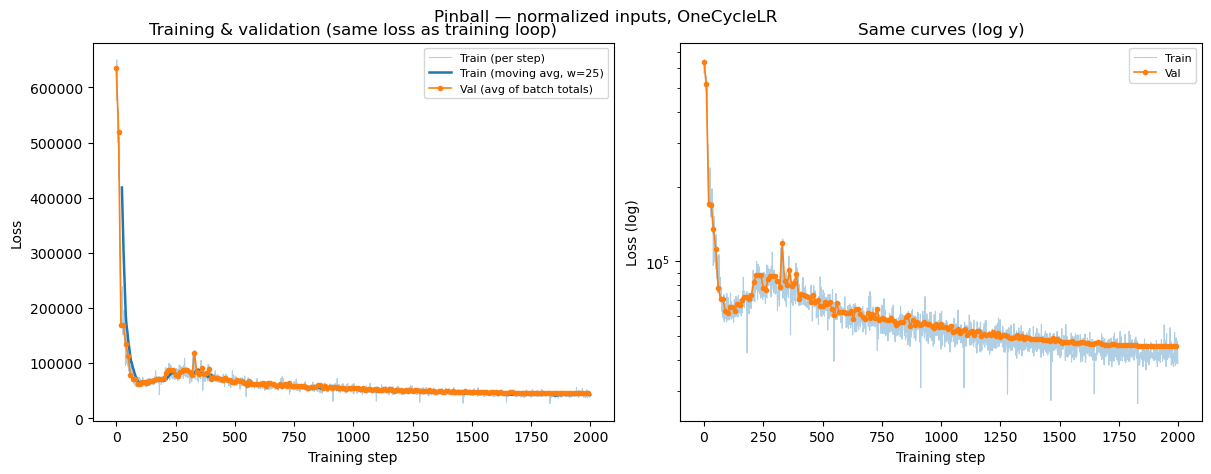

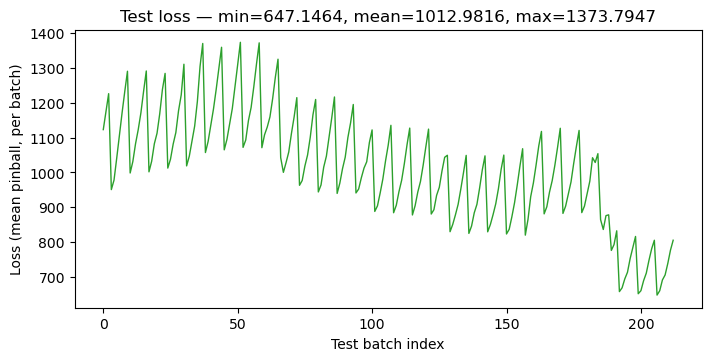

In [37]:
# Plot losses (set eval_interval to match train(..., eval_interval=...))
eval_interval = 10

train_steps = np.arange(len(train_losses))
val_steps = np.arange(len(val_losses), dtype=float) * eval_interval

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# Left: linear scale — train/val both use the same `loss` passed to train() (here: batch sum)
ax = axes[0]
ax.plot(train_steps, train_losses, color="C0", alpha=0.35, linewidth=0.8, label="Train (per step)")
if len(train_losses) >= 20:
    k = max(1, len(train_losses) // 80)
    kernel = np.ones(k) / k
    smooth = np.convolve(train_losses, kernel, mode="valid")
    ax.plot(np.arange(k - 1, len(train_losses)), smooth, color="C0", linewidth=1.8, label=f"Train (moving avg, w={k})")
if len(val_losses):
    ax.plot(
        val_steps,
        val_losses,
        color="C1",
        marker="o",
        markersize=3,
        linewidth=1.2,
        label="Val (avg of batch totals)",
    )
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.set_title("Training & validation (same loss as training loop)")
ax.legend(loc="upper right", fontsize=8)

# Right: log y
ax = axes[1]
ax.semilogy(train_steps, np.maximum(train_losses, 1e-12), color="C0", alpha=0.35, linewidth=0.8, label="Train")
if len(val_losses):
    ax.semilogy(val_steps, np.maximum(val_losses, 1e-12), color="C1", marker="o", markersize=3, linewidth=1.2, label="Val")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss (log)")
ax.set_title("Same curves (log y)")
ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Pinball — normalized inputs, OneCycleLR", fontsize=12, y=1.02)
plt.show()

# Test uses `og_loss` (mean per batch) — scale differs from train/val sum; shown separately
if len(test_loss):
    t = np.asarray(test_loss, dtype=float)
    min_t, mean_t, max_t = float(t.min()), float(t.mean()), float(t.max())
    fig2, ax2 = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
    ax2.plot(np.arange(len(t)), t, color="C2", linewidth=1.0)
    ax2.set_xlabel("Test batch index")
    ax2.set_ylabel("Loss (mean pinball, per batch)")
    ax2.set_title(f"Test loss — min={min_t:.4f}, mean={mean_t:.4f}, max={max_t:.4f}")
    plt.show()